In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error)

print('Libraries imported successfully.')

Libraries imported successfully.


In [3]:
cult = pd.read_excel(r"C:\Users\hp\Downloads\MENTOR SHIP\Mentor_Cult_fit_Ritik.xlsx")

In [4]:
cult.head()

,Unnamed: 0,ActivitySiteID,BookingEndDateTime,BookingStartTime,MaxBookees,Number_Booked,Price,BookingEndMonth,BookingEndDay,Booking_Start_Hour,Booking_Start_Min,Activity,Activity_Time,Activity_Duration
0,0,BRP,2018-04-01,9:00:00,35,29,1499,4,1,9,0,BodyCombat,09:00AM - 10:00AM,60
1,1,BRP,2018-04-01,10:00:00,20,15,1999,4,1,10,0,HattonABC,10:00AM - 11:00AM,60
2,2,HXP,2018-04-01,10:00:00,27,20,1999,4,1,10,0,StudioCyc,10:00AM - 11:00AM,60
3,3,HXP,2018-04-01,9:05:00,27,27,1999,4,1,9,5,StudioCyc,09:05AM - 10:05AM,60
4,4,TSC,2018-04-01,10:00:00,30,13,1299,4,1,10,0,BodyConditioning,10:00AM - 11:00AM,60


In [5]:
cult = cult.drop(
    columns=["Unnamed: 0"],
    errors="ignore"
)

In [7]:
cult["BookingEndDateTime"] = pd.to_datetime(
    cult["BookingEndDateTime"],
    errors="coerce"
)

In [8]:
cult["Number_Booked"] = pd.to_numeric(
    cult["Number_Booked"],
    errors="coerce"
)

In [9]:
cult = cult.dropna(
    subset=[
        "BookingEndDateTime",
        "Number_Booked"
    ]
)

In [10]:
daily_demand = (
    cult.groupby(
        cult["BookingEndDateTime"].dt.floor("D")
    )["Number_Booked"]
    .sum()
    .sort_index()
)

In [11]:
daily_demand = daily_demand.asfreq(
    "D",
    fill_value=0
)

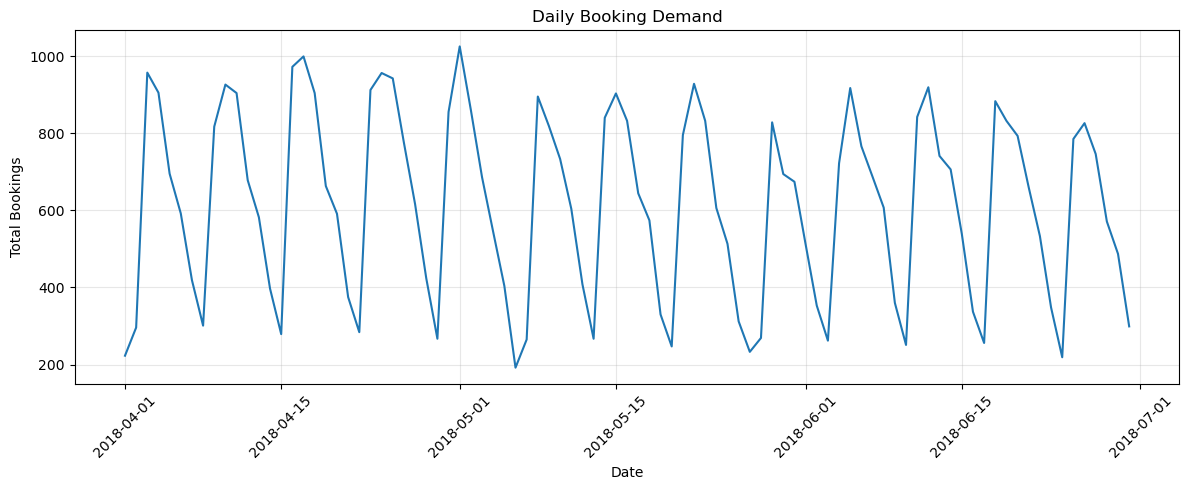

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_demand.index,
    daily_demand.values
)

plt.title(
    "Daily Booking Demand"
)

plt.xlabel("Date")
plt.ylabel("Total Bookings")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [13]:
test_size = int(
    len(daily_demand) * 0.20
)

train = daily_demand.iloc[:-test_size]

test = daily_demand.iloc[-test_size:]


print(
    "Training observations:",
    len(train)
)

print(
    "Testing observations:",
    len(test)
)


Training observations: 73
Testing observations: 18


In [14]:
model = SARIMAX(
    train,

    order=(1, 1, 1),

    seasonal_order=(1, 1, 1, 7),

    enforce_stationarity=False,

    enforce_invertibility=False
)

In [15]:
model_fit = model.fit(
    disp=False
)

In [17]:
forecast = model_fit.forecast(
    steps=len(test)
)

forecast.index = test.index

In [18]:
mae = mean_absolute_error(
    test,
    forecast
)

mse = mean_squared_error(
    test,
    forecast
)

rmse = np.sqrt(mse)


print("\nModel Evaluation")

print(
    "MAE:",
    round(mae, 2)
)

print(
    "MSE:",
    round(mse, 2)
)

print(
    "RMSE:",
    round(rmse, 2)
)


Model Evaluation
MAE: 51.39
MSE: 5847.67
RMSE: 76.47


In [19]:
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

print("\nActual vs Forecast")

print(
    comparison
)


Actual vs Forecast
                    Actual    Forecast
BookingEndDateTime                    
2018-06-13             741  816.214338
2018-06-14             706  638.695012
2018-06-15             539  521.029665
2018-06-16             337  329.664392
2018-06-17             256  207.528964
2018-06-18             883  636.410763
2018-06-19             832  887.685484
2018-06-20             793  795.551781
2018-06-21             659  633.000168
2018-06-22             533  520.510077
2018-06-23             348  323.109078
2018-06-24             219  202.506519
2018-06-25             785  649.647595
2018-06-26             826  881.311166
2018-06-27             746  787.979369
2018-06-28             571  623.743350
2018-06-29             487  510.670838
2018-06-30             299  313.949160


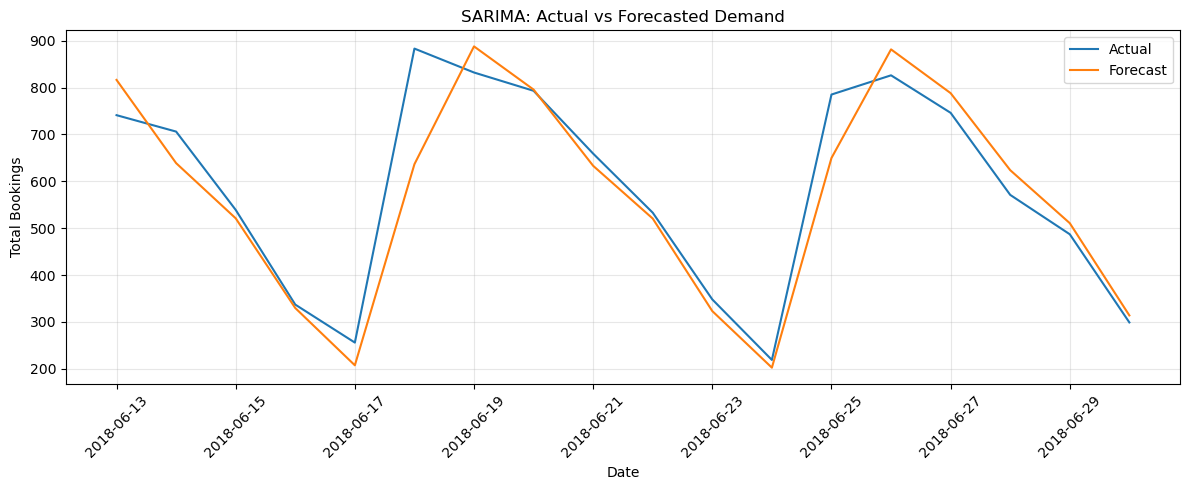

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="Forecast"
)

plt.title(
    "SARIMA: Actual vs Forecasted Demand"
)

plt.xlabel("Date")

plt.ylabel(
    "Total Bookings"
)

plt.legend()

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

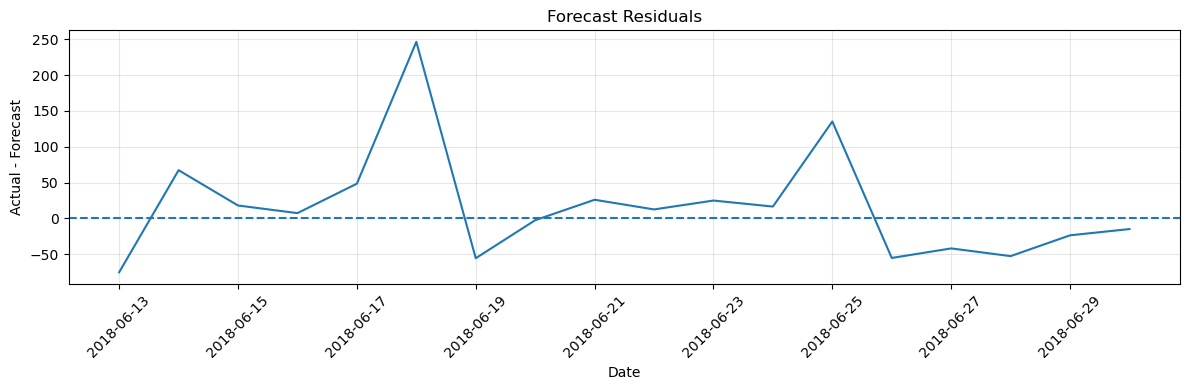

In [21]:
residuals = test - forecast


plt.figure(figsize=(12, 4))

plt.plot(
    residuals.index,
    residuals.values
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Forecast Residuals"
)

plt.xlabel("Date")

plt.ylabel(
    "Actual - Forecast"
)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


In [22]:
final_model = SARIMAX(
    daily_demand,

    order=(1, 1, 1),

    seasonal_order=(1, 1, 1, 7),

    enforce_stationarity=False,

    enforce_invertibility=False
).fit(
    disp=False
)


In [24]:
future_steps = 14

future_forecast = final_model.forecast(
    steps=future_steps
)

In [25]:
future_dates = pd.date_range(
    start=(
        daily_demand.index[-1]
        + pd.Timedelta(days=1)
    ),

    periods=future_steps,

    freq="D"
)


future_forecast.index = future_dates

In [26]:
print("\nNext 14 Days Forecast")

print(
    future_forecast
    .round(0)
    .astype(int)
)


Next 14 Days Forecast
2018-07-01    201
2018-07-02    664
2018-07-03    876
2018-07-04    781
2018-07-05    631
2018-07-06    513
2018-07-07    316
2018-07-08    198
2018-07-09    667
2018-07-10    863
2018-07-11    769
2018-07-12    617
2018-07-13    502
2018-07-14    306
Freq: D, Name: predicted_mean, dtype: int64


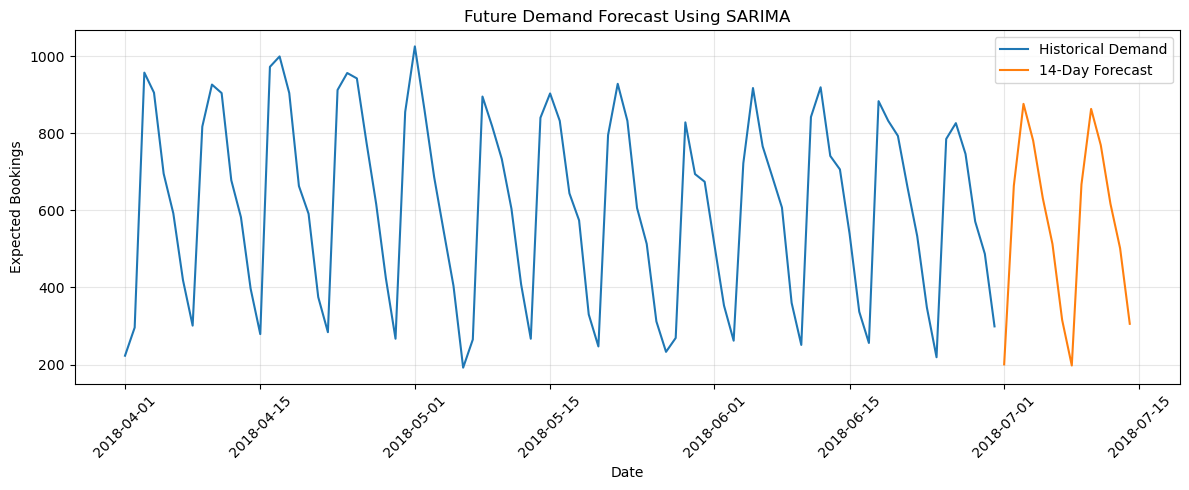

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_demand.index,
    daily_demand.values,
    label="Historical Demand"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="14-Day Forecast"
)

plt.title(
    "Future Demand Forecast Using SARIMA"
)

plt.xlabel("Date")

plt.ylabel(
    "Expected Bookings"
)

plt.legend()

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

For demand forecasting, I converted the class-level booking data into daily total demand using BookingEndDateTime and Number_Booked. After visualizing the time series, I identified a strong weekly seasonal pattern, so I selected a SARIMA model with a 7-day seasonal period. I used an 80-20 chronological train-test split for validation. The model achieved an MAE of 51.39, MSE of 5,847.67 and RMSE of 76.47 on the validation period. Finally, I retrained the model on the complete historical dataset and generated a 14-day demand forecast.